# 01 — Exploratory Data Analysis

Reads `wc2026.matches` via `read_table()` and produces basic sanity checks:
row count, date range, result distribution, draws %, home-win rate,
matches per team (top 20), matches per decade, neutral-venue share.

In [11]:
import sys
from pathlib import Path

# Make repo root importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from src.common.io import read_table

In [13]:
df = read_table("matches")
df["date"] = pd.to_datetime(df["date"])
print(f"Rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Rows: 0
Date range: NaT → NaT


## Result distribution

In [14]:
result_dist = df["result"].value_counts(normalize=True).mul(100).round(2)
print("Result distribution (%)")
print(result_dist.to_string())

draw_pct = result_dist.get("D", 0)
home_win_pct = result_dist.get("H", 0)
print(f"\nDraws:      {draw_pct:.1f}%  (sanity: 22–25%)")
print(f"Home wins:  {home_win_pct:.1f}%  (sanity: ~44–47%)")

Result distribution (%)
Series([], )

Draws:      0.0%  (sanity: 22–25%)
Home wins:  0.0%  (sanity: ~44–47%)


IndexError: index 0 is out of bounds for axis 0 with size 0

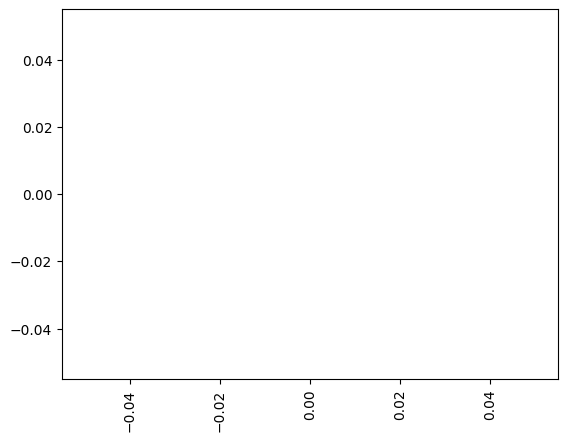

In [15]:
fig, ax = plt.subplots()
result_dist.plot.bar(ax=ax, color=["steelblue", "gray", "tomato"])
ax.set_title("Result distribution (%)")
ax.set_xlabel("Result (H=home win, D=draw, A=away win)")
ax.set_ylabel("%")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Matches per team (top 20)

In [ ]:
home_counts = df["home_team"].value_counts()
away_counts = df["away_team"].value_counts()
total_by_team = (home_counts.add(away_counts, fill_value=0)).astype(int)
top20 = total_by_team.nlargest(20)
print("Top 20 teams by match count:")
print(top20.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
top20.plot.bar(ax=ax, color="steelblue")
ax.set_title("Top 20 teams by match count")
ax.set_ylabel("Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Matches per decade

In [ ]:
df["decade"] = (df["date"].dt.year // 10 * 10).astype(str) + "s"
by_decade = df["decade"].value_counts().sort_index()
print("Matches per decade:")
print(by_decade.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
by_decade.plot.bar(ax=ax, color="steelblue")
ax.set_title("Matches per decade")
ax.set_ylabel("Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Neutral-venue share

In [ ]:
neutral_pct = df["neutral"].mean() * 100
print(f"Neutral venue: {neutral_pct:.1f}% of matches")

## Sanity assertions

In [ ]:
assert df['date'].min().year <= 1900, f"Earliest date too late: {df['date'].min().date()}"
assert df['date'].max().year >= 2025, f"Latest date too early: {df['date'].max().date()}"
assert 22 <= draw_pct <= 25, f"Draw % out of range: {draw_pct:.1f}%"
assert len(df) >= 45_000, f"Too few rows: {len(df)}"
print("All sanity checks passed.")